In [191]:
# ==================================================
# Data Manipulation
# ==================================================

import pandas as pd
import numpy as np

# ==================================================
# Visualization
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# Machine Learning Utilities
# ==================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==================================================
# Baseline Model
# ==================================================

from sklearn.linear_model import LogisticRegression

# ==================================================
# Evaluation Metrics
# ==================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [192]:
# Load cleaned dataset generated during EDA

df = pd.read_csv("../datasets/diabetes_clean.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,Obese,40-50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,Overweight,30-40
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,Normal,30-40
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,20-30
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,30-40


In [193]:
# --------------------------------------------------
# Feature Matrix
# --------------------------------------------------

X = df.drop(
    columns=[
        'Outcome',
        'BMI_Category',
        'Age_Group'
    ]
)

# --------------------------------------------------
# Target Variable
# --------------------------------------------------

y = df['Outcome']

In [194]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [195]:
# Initialize scaler

scaler = StandardScaler()

# Fit on training data only

X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data

X_test_scaled = scaler.transform(X_test)

In [196]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [197]:
# Predicted Classes

y_pred = lr_model.predict(
    X_test_scaled
)

# Predicted Probabilities

y_prob = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

In [198]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [199]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Value
0,Accuracy,0.707792
1,Precision,0.600000
2,Recall,0.500000
3,F1 Score,0.545455
4,ROC-AUC,0.812963


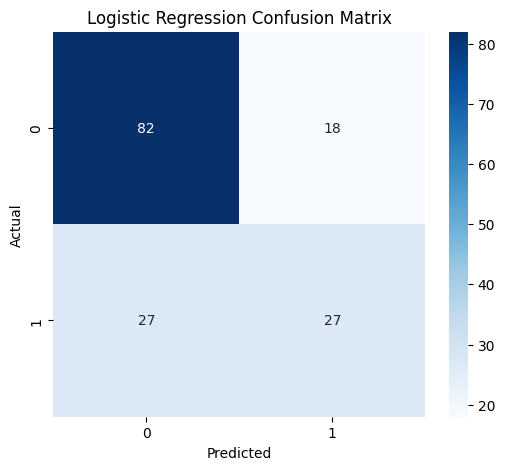

In [200]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [201]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



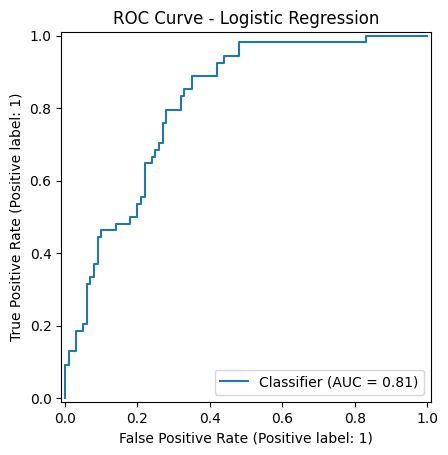

In [202]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "ROC Curve - Logistic Regression"
)

plt.show()

In [203]:
feature_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": lr_model.coef_[0]
    }
)

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
1,Glucose,1.182511
5,BMI,0.688735
0,Pregnancies,0.377502
6,DiabetesPedigreeFunction,0.233386
7,Age,0.147798
3,SkinThickness,0.028225
2,BloodPressure,-0.044066
4,Insulin,-0.066157


In [204]:
import pickle

with open(
    "../models/logistic_regression.pkl",
    "wb"
) as f:
    pickle.dump(
        lr_model,
        f
    )

***A Logistic Regression baseline model was developed for diabetes risk prediction. While the model achieved a ROC-AUC score of 0.813, indicating strong class separability, recall remained limited at 50%, suggesting that a substantial proportion of diabetic patients were not identified. Given the healthcare context, improving recall is a priority for subsequent model iterations.***

In [205]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [206]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(
    X_test
)[:,1]

In [207]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

In [208]:
rf_importance = pd.DataFrame(
    {
        "Feature": X.columns,
        "Importance": rf_model.feature_importances_
    }
)

rf_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
1,Glucose,0.365058
5,BMI,0.167366
7,Age,0.119850
4,Insulin,0.099349
6,DiabetesPedigreeFunction,0.083487
0,Pregnancies,0.064073
3,SkinThickness,0.056736
2,BloodPressure,0.044081


In [209]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [210]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [211]:
xgb_pred = xgb_model.predict(
    X_test
)

xgb_prob = xgb_model.predict_proba(
    X_test
)[:,1]

In [212]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_prob
)

In [213]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision":[
        precision,
        rf_precision,
        xgb_precision
    ],

    "Recall":[
        recall,
        rf_recall,
        xgb_recall
    ],

    "F1":[
        f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC":[
        roc_auc,
        rf_auc,
        xgb_auc
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963
1,Random Forest,0.740260,0.659091,0.537037,0.591837,0.807407
2,XGBoost,0.766234,0.687500,0.611111,0.647059,0.822037


In [214]:
from sklearn.model_selection import cross_val_score

In [215]:
lr_cv = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("LR Mean ROC-AUC:", lr_cv.mean())

LR Mean ROC-AUC: 0.8432295127353268


In [216]:
rf_cv = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("RF Mean ROC-AUC:", rf_cv.mean())

RF Mean ROC-AUC: 0.835795957918051


In [217]:
xgb_cv = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("XGB Mean ROC-AUC:", xgb_cv.mean())

XGB Mean ROC-AUC: 0.8140019379844962


In [218]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "CV ROC-AUC": [
        lr_cv.mean(),
        rf_cv.mean(),
        xgb_cv.mean()
    ]
})

cv_results

,Model,CV ROC-AUC
0,Logistic Regression,0.843230
1,Random Forest,0.835796
2,XGBoost,0.814002


In [219]:
import pickle

with open(
    "../models/best_model.pkl",
    "wb"
) as f:
    pickle.dump(
        lr_model,
        f
    )

In [220]:
with open(
    "../models/scaler.pkl",
    "wb"
) as f:
    pickle.dump(
        scaler,
        f
    )

**SHAP**

In [221]:
import sys
print(sys.executable)

e:\medtwin-ai\venv\Scripts\python.exe


In [222]:
import shap

print(shap.__version__)

0.52.0


In [223]:
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

In [224]:
# ==========================================
# Create SHAP Explainer
# ==========================================

explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled_df
)

Background dataset has 614 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=614 when initializing the masker.


In [225]:
import pickle

with open(
    "../models/shap_explainer.pkl",
    "wb"
) as f:
    pickle.dump(
        explainer,
        f
    )

In [226]:
# ==========================================
# Calculate SHAP Values
# ==========================================

shap_values = explainer(
    X_test_scaled_df
)

In [227]:
print(shap_values.values.shape)

(154, 8)


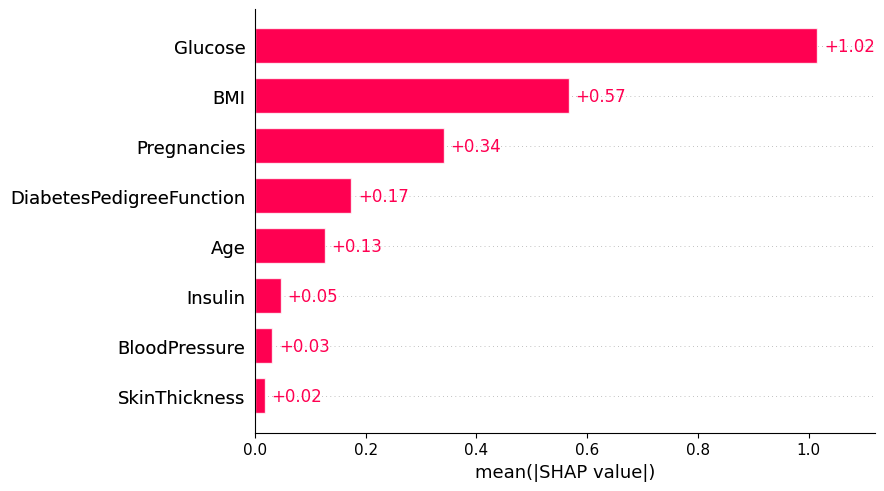

In [228]:
# ==========================================
# Global Feature Importance
# ==========================================

shap.plots.bar(
    shap_values
)

Interpretation:

Glucose has the strongest influence on diabetes prediction.
BMI is the second most important factor.
Age contributes significantly.
DiabetesPedigreeFunction captures family/genetic risk.

This is good because it aligns with real medical knowledge.

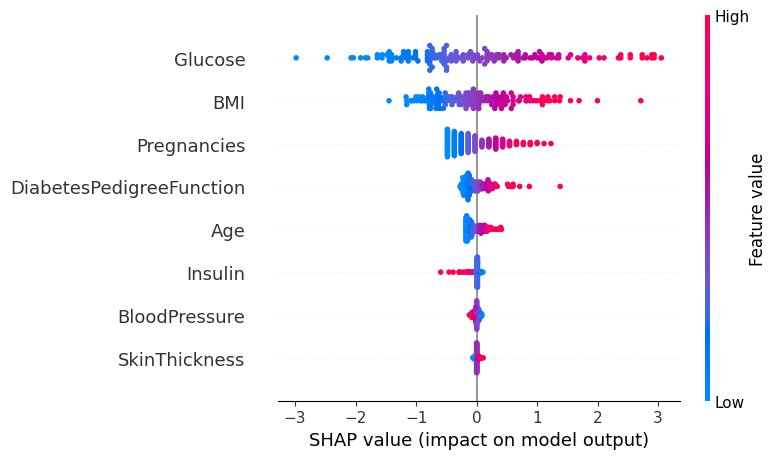

In [229]:
shap.summary_plot(
    shap_values,
    X_test_scaled_df
)

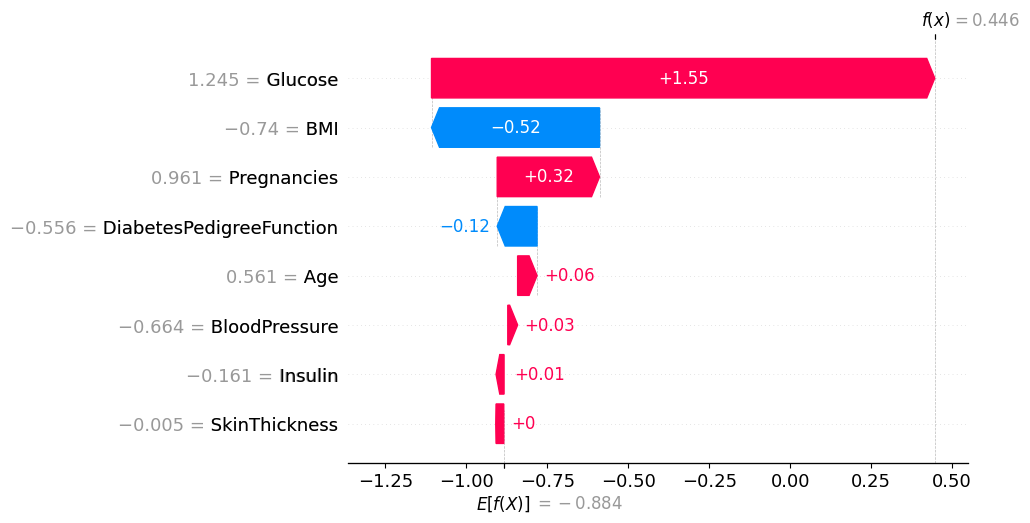

In [230]:
patient_index = 0

shap.plots.waterfall(
    shap_values[patient_index]
)

## Explainable AI Findings

SHAP analysis was used to interpret model predictions.

Key Findings:
- Glucose was the most influential predictor.
- BMI and Age significantly impacted diabetes risk.
- Patient-level explanations provided transparency by highlighting feature contributions to individual predictions.

The explainability component improves trustworthiness and clinical usability of the AI system.

**Hyperparameter Tuning**

In [231]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [232]:
# ==========================================
# Hyperparameter Grid
# ==========================================

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [233]:
# ==========================================
# Grid Search
# ==========================================

grid_lr = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_lr.fit(
    X_train_scaled,
    y_train
)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='roc_auc')

In [234]:
print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest ROC-AUC:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}

Best ROC-AUC:
0.8433457918050941


In [235]:
best_lr = grid_lr.best_estimator_

In [236]:
tuned_pred = best_lr.predict(
    X_test_scaled
)

tuned_prob = best_lr.predict_proba(
    X_test_scaled
)[:,1]

In [237]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred
)

tuned_auc = roc_auc_score(
    y_test,
    tuned_prob
)

In [238]:
comparison_tuned = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Before Tuning": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ],
    "After Tuning": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_auc
    ]
})

comparison_tuned

,Metric,Before Tuning,After Tuning
0,Accuracy,0.707792,0.694805
1,Precision,0.600000,0.574468
2,Recall,0.500000,0.500000
3,F1 Score,0.545455,0.534653
4,ROC-AUC,0.812963,0.812778
